t = 2.603518493104905
one-tailed p = 0.02991312684453551


/var/folders/zf/l6yy25q51wgch0_2q1h5b2t80000gn/T/ipykernel_16805/865071196.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right",fontsize=25)
/var/folders/zf/l6yy25q51wgch0_2q1h5b2t80000gn/T/ipykernel_16805/865071196.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=25)


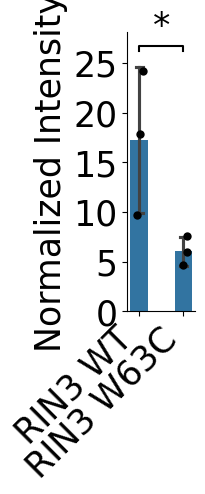

In [ ]:
from scipy import stats
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Normalized intensity data for RIN3 WT and RIN3 W63C
group1 = [9.655534494,24.23777591,17.84024593]
group2 = [4.639085355,7.537352462,5.952749405]

t_stat, p_two = stats.ttest_ind(group1, group2, equal_var=True)

# convert to one-tailed p-value (same logic Excel uses)
p_one = p_two / 2 if t_stat > 0 else 1 - p_two / 2

print("t =", t_stat)
print("one-tailed p =", p_one)

# Prepare dataframe
df = pd.DataFrame({
    "value": group1 + group2,
    "group": ["RIN3 WT"] * len(group1) + ["RIN3 W63C"] * len(group2)
})

# Plot
plt.figure(figsize=(2, 5))
ax = sns.barplot(
    data=df,
    x="group",
    y="value",
    estimator=np.mean,
    errorbar="sd",
    capsize=0.15,
    width=0.4
)

sns.stripplot(
    data=df,
    x="group",
    y="value",
    color="black",
    size=6,
    jitter=True,
    ax=ax
)


ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right",fontsize=25)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=25)
# Significance
p_value = p_one
y_max = df["value"].max()
h = 2
x1, x2 = 0, 1

ax.plot(
    [x1, x1, x2, x2],
    [y_max + h, y_max + h + 0.5, y_max + h + 0.5, y_max + h],
    lw=1.5,
    c="black"
)

ax.text(
    (x1 + x2) / 2,
    y_max + h + 0.7,
    "*",
    ha="center",
    va="bottom",
    fontsize=25
)

# Labels
ax.set_ylabel("Normalized Intensity", fontsize=25)
ax.set_xlabel("",fontsize=25)

sns.despine()
plt.tight_layout()
plt.savefig('RIN3_WT_vs_W63C_barplot.svg')
plt.show()